# Clean up, fix and fill data 

## Import libraries

In [6]:
import pandas as pd
import numpy as np 
import os 
import matplotlib.pyplot as plt
import gc
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns 
from sqlalchemy import text
import sys


## Import or load up the csv

In [7]:
names_cols = ["Ciudad", "Fecha", "Producto", "Tipo_Producto", "Cantidad","Precio_Unitario", "Tipo_Venta", "Tipo_Cliente","Descuento", "Costo_Envio", "Venta_Total"]

ruta_path = '../Data/RWventas.csv'

try:
     df = pd.read_csv(ruta_path, header=0, names=names_cols, encoding='utf-8')
     print("File uploaded with codification: UTF-8")
except  UnicodeDecodeError:
     df = pd.read_csv(ruta_path, header=0, names=names_cols, encoding='latin-1')
     print("File uploaded with codification: Latin-1")

print(f"Dimensiones cargadas: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()
     

File uploaded with codification: UTF-8
Dimensiones cargadas: 1000000 rows x 11 columns


,Ciudad,Fecha,Producto,Tipo_Producto,Cantidad,Precio_Unitario,Tipo_Venta,Tipo_Cliente,Descuento,Costo_Envio,Venta_Total
0,Antofagasta,2025-11-28,Leche,Alimento_Percedero,2.0,1587.0,Online,Minorista,0.2,0.0,2539.0
1,Monterrey,2025-11-29,Leche,Hogar,5.0,NaN,Call_Center,Mayorista,0.2,10000.0,20412.0
2,Valparaíso,2025-12-07,Café,Hogar,1.0,3882.0,Tienda_Física,Minorista,0.0,0.0,3882.0
3,Sevilla,2025-12-01,Té,Snack,5.0,2060.0,Distribuidor,Corporativo,0.15,0.0,8755.0
4,Sevilla,2025-11-18,Chocolate,Snack,1.0,3712.0,Online,Minorista,0.05,250000.0,8526.0


## Fix the ruido

### Noise audit

In [8]:
noise_pattern = r"[#@*©‰?]"
critical_garbage = "???" 

print(f"\n{'='*50}")
print(" AUDIT REPORT: GENERAL NOISE DETECTED")
print(f"{'='*50}")

total_noise_cells = 0
for col in df.columns:
    noise_mask = df[col].astype(str).str.contains(noise_pattern, regex=True, na=False)
    noise_count = noise_mask.sum()
    
    if noise_count > 0:
        total_noise_cells += noise_count
        print(f"Column '{col}': {noise_count} cells contain noise.")

print(f"\n---> TOTAL NOISE FOUND: {total_noise_cells}")


 AUDIT REPORT: GENERAL NOISE DETECTED
Column 'Ciudad': 1050 cells contain noise.
Column 'Fecha': 1058 cells contain noise.
Column 'Producto': 979 cells contain noise.
Column 'Tipo_Producto': 1067 cells contain noise.
Column 'Cantidad': 3313 cells contain noise.
Column 'Precio_Unitario': 3341 cells contain noise.
Column 'Tipo_Venta': 1008 cells contain noise.
Column 'Tipo_Cliente': 1019 cells contain noise.
Column 'Descuento': 3340 cells contain noise.
Column 'Costo_Envio': 3350 cells contain noise.
Column 'Venta_Total': 3288 cells contain noise.

---> TOTAL NOISE FOUND: 22813


### Audit ??? data 

In [9]:
print(f"\n\n{'='*50}")
print(f" AUDIT REPORT: FUTURE MISSING VALUES ('{critical_garbage}')")
print(f"{'='*50}")
total_missing_candidates = 0

for col in df.columns:
    missing_mask = df[col].astype(str).str.strip() == critical_garbage
    missing_count = missing_mask.sum()

    if missing_count > 0:
        total_missing_candidates += missing_count
        print(f"Column '{col}': {missing_count} cells are '{critical_garbage}' -> Will become NaN.")

print(f"\n---> TOTAL FUTURE MISSING VALUES : {total_missing_candidates}")



 AUDIT REPORT: FUTURE MISSING VALUES ('???')
Column 'Cantidad': 3313 cells are '???' -> Will become NaN.
Column 'Precio_Unitario': 3341 cells are '???' -> Will become NaN.
Column 'Descuento': 3340 cells are '???' -> Will become NaN.
Column 'Costo_Envio': 3350 cells are '???' -> Will become NaN.
Column 'Venta_Total': 3288 cells are '???' -> Will become NaN.

---> TOTAL FUTURE MISSING VALUES : 16632


### Audit WHITESPACE DETECTION

In [10]:


total_whitespace_errors = 0
for col in df.columns:
    whitespace_mask = df[col].astype(str).str.startswith(' ') | df[col].astype(str).str.endswith(' ')
    
    error_count = whitespace_mask.sum()
    
    if error_count > 0:
        total_whitespace_errors += error_count
        print(f"Column '{col}': {error_count} rows have hidden whitespace.")
        example_value = df.loc[whitespace_mask, col].iloc[0]
        print(f"Example detected: '{example_value}'")

print(f"\n---> TOTAL WHITESPACE ERRORS FOUND: {total_whitespace_errors}")

Column 'Ciudad': 1037 rows have hidden whitespace.
Example detected: '  Barcelona   '
Column 'Fecha': 1069 rows have hidden whitespace.
Example detected: '  2025-11-10   '
Column 'Producto': 1038 rows have hidden whitespace.
Example detected: '  Té   '
Column 'Tipo_Producto': 1008 rows have hidden whitespace.
Example detected: '  Hogar   '
Column 'Tipo_Venta': 1077 rows have hidden whitespace.
Example detected: '  Online   '
Column 'Tipo_Cliente': 1036 rows have hidden whitespace.
Example detected: '  Corporativo   '

---> TOTAL WHITESPACE ERRORS FOUND: 6265


## FIXING WHITESPACE ERRORS

In [11]:
total_trimmed_cells = 0

for col in df.columns:
    needs_trimming_mask = df[col].astype(str).str.startswith(' ') | df[col].astype(str).str.endswith(' ')
    
    count = needs_trimming_mask.sum()
    
    if count > 0:
        total_trimmed_cells += count
        df[col] = df[col].astype(str).str.strip()
        
        print(f"Column '{col}': Cleaned {count} rows.")

print("-" * 40)
print(f"TOTAL CELLS TRIMMED: {total_trimmed_cells}")
print("-" * 40)

Column 'Ciudad': Cleaned 1037 rows.
Column 'Fecha': Cleaned 1069 rows.
Column 'Producto': Cleaned 1038 rows.
Column 'Tipo_Producto': Cleaned 1008 rows.
Column 'Tipo_Venta': Cleaned 1077 rows.
Column 'Tipo_Cliente': Cleaned 1036 rows.
----------------------------------------
TOTAL CELLS TRIMMED: 6265
----------------------------------------


## REMOVING GENERAL NOISE

In [12]:
total_cleaned_cells = 0

for col in df.columns:
    noise_mask = df[col].astype(str).str.contains(noise_pattern, regex=True, na=False)
    cells_cleaned = noise_mask.sum()
    
    if cells_cleaned > 0:
        total_cleaned_cells += cells_cleaned
        
        df[col] = df[col].astype(str).str.replace(noise_pattern, '', regex=True).str.strip()
        
        print(f"Column '{col}': Cleaned {cells_cleaned} cells.")

print("-" * 40)
print(f"TOTAL CELLS CLEANED: {total_cleaned_cells}")
print("-" * 40)

print(df.head())

Column 'Ciudad': Cleaned 1050 cells.
Column 'Fecha': Cleaned 1058 cells.
Column 'Producto': Cleaned 979 cells.
Column 'Tipo_Producto': Cleaned 1067 cells.
Column 'Cantidad': Cleaned 3313 cells.
Column 'Precio_Unitario': Cleaned 3341 cells.
Column 'Tipo_Venta': Cleaned 1008 cells.
Column 'Tipo_Cliente': Cleaned 1019 cells.
Column 'Descuento': Cleaned 3340 cells.
Column 'Costo_Envio': Cleaned 3350 cells.
Column 'Venta_Total': Cleaned 3288 cells.
----------------------------------------
TOTAL CELLS CLEANED: 22813
----------------------------------------
        Ciudad       Fecha   Producto       Tipo_Producto Cantidad  \
0  Antofagasta  2025-11-28      Leche  Alimento_Percedero      2.0   
1    Monterrey  2025-11-29      Leche               Hogar      5.0   
2   Valparaíso  2025-12-07       Café               Hogar      1.0   
3      Sevilla  2025-12-01         Té               Snack      5.0   
4      Sevilla  2025-11-18  Chocolate               Snack      1.0   

  Precio_Unitario     

## ESTANDARIZACIÓN DE TEXTO Title Case

In [13]:
# Lista de columnas categóricas a arreglar
cols_texto = ['Tipo_Venta', 'Tipo_Cliente', 'Producto', 'Ciudad', 'Tipo_Producto']

for col in cols_texto:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()
        print(f"Columna '{col}' estandarizada (Ej: {df[col].iloc[0]})")

print("\nVerificación de Unicidad (Ejemplo Tipo_Cliente):")
print(df['Tipo_Cliente'].unique())

Columna 'Tipo_Venta' estandarizada (Ej: Online)
Columna 'Tipo_Cliente' estandarizada (Ej: Minorista)
Columna 'Producto' estandarizada (Ej: Leche)
Columna 'Ciudad' estandarizada (Ej: Antofagasta)
Columna 'Tipo_Producto' estandarizada (Ej: Alimento_Percedero)

Verificación de Unicidad (Ejemplo Tipo_Cliente):
['Minorista' 'Mayorista' 'Corporativo' 'Gobierno' 'Nan']


## STANDARDIZATION & TYPE CONVERSION

In [14]:


df = df.replace(r'^\s*$', np.nan, regex=True)


numeric_cols = ['Cantidad', 'Precio_Unitario', 'Descuento', 'Costo_Envio', 'Venta_Total']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    print(f"• Column '{col}' converted to Float (Numeric).")


print("\n===  MISSING VALUES REPORT (READY FOR IMPUTATION) ===")
missing_status = df[numeric_cols].isna().sum()
print(missing_status[missing_status > 0])

• Column 'Cantidad' converted to Float (Numeric).
• Column 'Precio_Unitario' converted to Float (Numeric).
• Column 'Descuento' converted to Float (Numeric).
• Column 'Costo_Envio' converted to Float (Numeric).
• Column 'Venta_Total' converted to Float (Numeric).

===  MISSING VALUES REPORT (READY FOR IMPUTATION) ===
Cantidad           7843
Precio_Unitario    7796
Descuento          7843
Costo_Envio        7819
Venta_Total        7816
dtype: int64


## DATE FORMAT VALIDATION & CONVERSION

In [15]:
converted_dates = pd.to_datetime(df['Fecha'], errors='coerce')
temp_str_col = df['Fecha'].astype(str).str.strip()
original_not_empty = (temp_str_col != '') & (temp_str_col.str.lower() != 'nan') & df['Fecha'].notna()
is_invalid_format = converted_dates.isna() & original_not_empty
invalid_count = is_invalid_format.sum()

if invalid_count > 0:
    print(f"CRITICAL ERROR: Found {invalid_count} rows with invalid date text (junk data).")
    print("   Samples of invalid data:")
    print(df.loc[is_invalid_format, 'Fecha'].head())
else:
    print("Format Check Passed: No unreadable text found (all failures are just Empty/Missing values).")

df['Fecha'] = converted_dates
missing_dates_count = df['Fecha'].isna().sum()
print("-" * 40)
print(f"ℹSTATUS REPORT:")
print(f"   - Valid Dates: {df['Fecha'].notna().sum()}")
print(f"   - Missing Dates (NaT): {missing_dates_count} (To be handled later)")
print("-" * 40)


print(f"Column 'Fecha' current type: {df['Fecha'].dtype}")

Format Check Passed: No unreadable text found (all failures are just Empty/Missing values).
----------------------------------------
ℹSTATUS REPORT:
   - Valid Dates: 995380
   - Missing Dates (NaT): 4620 (To be handled later)
----------------------------------------
Column 'Fecha' current type: datetime64[ns]


### STANDARDIZING CATEGORICAL MISSING VALUES

In [16]:
print(f"\n{'='*50}")
print(" 🔄 RECUPERANDO NULOS REALES (Fix 'Nan')")
print(f"{'='*50}")

# 1. Reemplazo PODEROSO usando Regex
# Esto atrapa: "Nan", "nan", "NAN", "None", "none" y espacios vacíos
df.replace(r'^[Nn]an$', np.nan, regex=True, inplace=True)
df.replace(r'^[Nn]one$', np.nan, regex=True, inplace=True)
df.replace(r'^\s*$', np.nan, regex=True, inplace=True) # Tu línea original mejorada

# 2. Verificación
nulos_ahora = df.isnull().sum().sum()
print(f"✅ Se han recuperado {nulos_ahora} valores nulos reales.")
print("\nDetalle por columna:")
print(df.isnull().sum())


 🔄 RECUPERANDO NULOS REALES (Fix 'Nan')
✅ Se han recuperado 66463 valores nulos reales.

Detalle por columna:
Ciudad             4551
Fecha              4620
Producto           4605
Tipo_Producto      4626
Cantidad           7843
Precio_Unitario    7796
Tipo_Venta         4523
Tipo_Cliente       4421
Descuento          7843
Costo_Envio        7819
Venta_Total        7816
dtype: int64


## MISSING VALUES VISUALIZATION

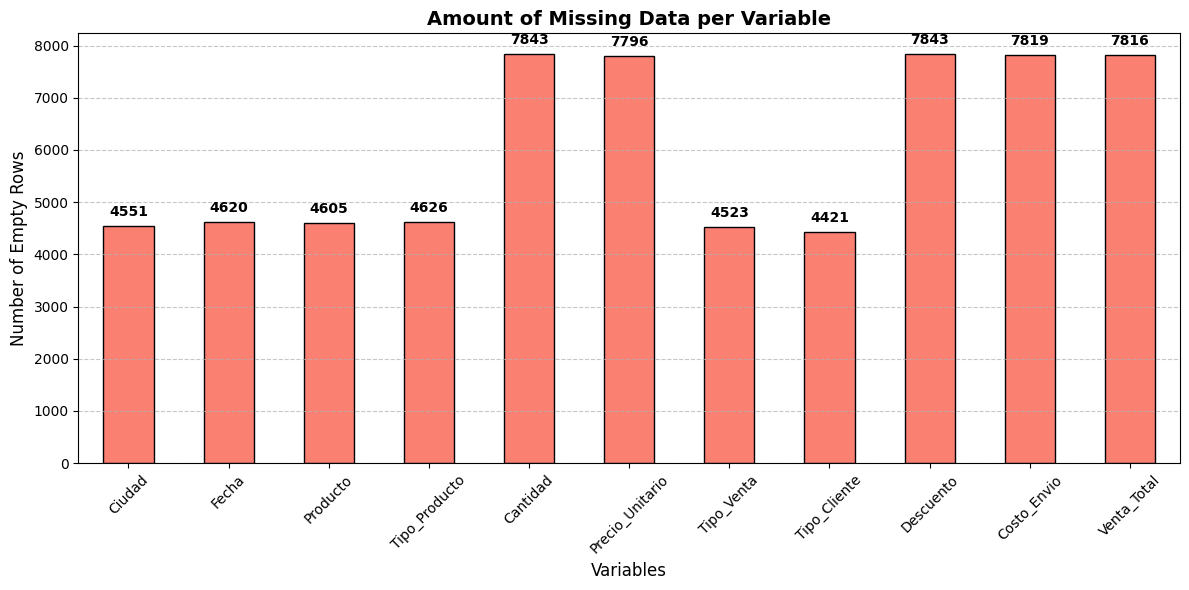


Detailed Count:
Ciudad             4551
Fecha              4620
Producto           4605
Tipo_Producto      4626
Cantidad           7843
Precio_Unitario    7796
Tipo_Venta         4523
Tipo_Cliente       4421
Descuento          7843
Costo_Envio        7819
Venta_Total        7816
dtype: int64


In [17]:
all_nulls = df.isnull().sum()

missing_only = all_nulls[all_nulls > 0]

if not missing_only.empty:
    plt.figure(figsize=(12, 6))

    ax = missing_only.plot(kind='bar', color='salmon', edgecolor='black')
    
    plt.title('Amount of Missing Data per Variable', fontsize=14, fontweight='bold')
    plt.ylabel('Number of Empty Rows', fontsize=12)
    plt.xlabel('Variables', fontsize=12)
    plt.xticks(rotation=45) 
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    for p in ax.patches:
        ax.annotate(str(int(p.get_height())), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')
    
    plt.tight_layout() 
    plt.show()
    
    print("\nDetailed Count:")
    print(missing_only)

else:
    print("SUCCESS: There are no missing values remaining!")

## IMPUTING MISSING DATES (TEMPORAL PROXIMITY)

In [18]:
if 'Origen_Dato' not in df.columns:
    df['Origen_Dato'] = 'Original'
date_mask = df['Fecha'].isnull()
missing_count = date_mask.sum()

if missing_count > 0:
    print(f"Found {missing_count} rows with missing dates.")
    print("Applying strategy: Forward Fill & Backward Fill...")
    df.loc[date_mask, 'Origen_Dato'] = 'Proximidad Temporal'

    #Execute IMPUTATION
    df['Fecha'] = df['Fecha'].ffill()
    df['Fecha'] = df['Fecha'].bfill()

    print(f"Successfully imputed {missing_count} missing dates.")

    print(df.loc[date_mask, ['Fecha', 'Origen_Dato']].head())
else:
    print(" No missing dates found.")



Found 4620 rows with missing dates.
Applying strategy: Forward Fill & Backward Fill...
Successfully imputed 4620 missing dates.
         Fecha          Origen_Dato
169 2025-11-28  Proximidad Temporal
252 2025-11-25  Proximidad Temporal
557 2025-11-28  Proximidad Temporal
712 2025-11-14  Proximidad Temporal
768 2025-11-23  Proximidad Temporal


## ADVANCED MATHEMATICAL IMPUTATION

In [19]:
def update_audit_trail(dataframe, mask, new_label):
    #Initialize if column missing
    if 'Origen_Dato' not in dataframe.columns:
        dataframe['Origen_Dato'] = 'Original'
    mask_original = mask & (dataframe['Origen_Dato'] == 'Original')
    dataframe.loc[mask_original, 'Origen_Dato'] = new_label
    
    mask_modified = mask & (dataframe['Origen_Dato'] != 'Original')
    
    if mask_modified.sum() > 0:
        dataframe.loc[mask_modified, 'Origen_Dato'] = dataframe.loc[mask_modified, 'Origen_Dato'].apply(
            lambda x: x + ', ' + new_label if new_label not in x else x
        )
print("--- Phase 1: Logic Sanity Checks ---")

#Discounts > 100% or Negative
mask_bad_disc = (df['Descuento'] > 1) | (df['Descuento'] < 0)
if mask_bad_disc.sum() > 0:
    print(f"Fixed {mask_bad_disc.sum()} illogical Discounts (<0 or >1).")
    df.loc[mask_bad_disc, 'Descuento'] = 0
# Check 2: Shipping Cost > Total Sale
mask_bad_ship = df['Costo_Envio'] > df['Venta_Total']
if mask_bad_ship.sum() > 0:
    print(f"Fixed {mask_bad_ship.sum()} Shipping Costs higher than Total Sale.")
    df.loc[mask_bad_ship, 'Costo_Envio'] = 0

#IMPUTATION BY FORMULA
audit_label = 'Formula matematica'



--- Phase 1: Logic Sanity Checks ---
Fixed 1615 Shipping Costs higher than Total Sale.


###  A. VENTA_TOTAL -> Formula: (Price * Qty * (1 - Disc)) + Ship

In [20]:
mask_total = df['Venta_Total'].isnull() & df['Precio_Unitario'].notnull() & df['Cantidad'].notnull()
if mask_total.sum() > 0:
    print(f"Calculating {mask_total.sum()} missing Totals...")
    update_audit_trail(df, mask_total, audit_label)
    df.loc[mask_total, 'Venta_Total'] = ((df['Precio_Unitario'] * df['Cantidad']) * (1 - df['Descuento'].fillna(0))) + df['Costo_Envio'].fillna(0)

Calculating 7689 missing Totals...


### B. COSTO_ENVIO -> Formula: Total - (Price * Qty * (1 - Disc))

In [21]:
mask_ship = df['Costo_Envio'].isnull() & df['Venta_Total'].notnull() & df['Precio_Unitario'].notnull() & df['Cantidad'].notnull()
if mask_ship.sum() > 0:
    print(f"Calculating {mask_ship.sum()} missing Shipping Costs...")
    update_audit_trail(df, mask_ship, audit_label)
    subtotal = (df['Precio_Unitario'] * df['Cantidad']) * (1 - df['Descuento'].fillna(0))
    calculated_ship = df['Venta_Total'] - subtotal
    df.loc[mask_ship, 'Costo_Envio'] = calculated_ship.clip(lower=0)



Calculating 7700 missing Shipping Costs...


### C. DESCUENTO -> Formula: 1 - ((Total - Ship) / (Price * Qty))

In [22]:
mask_disc = (df['Descuento'].isnull() & df['Venta_Total'].notnull() & df['Costo_Envio'].notnull() & 
             df['Precio_Unitario'].notnull() & df['Cantidad'].notnull() & 
             ((df['Precio_Unitario'] * df['Cantidad']) > 0))
if mask_disc.sum() > 0:
    print(f"Calculating {mask_disc.sum()} missing Discounts...")
    update_audit_trail(df, mask_disc, audit_label)

    numerator = df['Venta_Total'] - df['Costo_Envio']
    denominator = df['Precio_Unitario'] * df['Cantidad']
    df.loc[mask_disc, 'Descuento'] = 1 - (numerator / denominator)



Calculating 7719 missing Discounts...


### D. PRECIO_UNITARIO -> Formula: (Total - Ship) / (Qty * (1 - Disc))


In [23]:
mask_price = df['Precio_Unitario'].isnull() & df['Venta_Total'].notnull() & df['Cantidad'].notnull() & (df['Cantidad'] > 0)
denominator_check = df['Cantidad'] * (1 - df['Descuento'].fillna(0))
mask_price = mask_price & (denominator_check != 0)

if mask_price.sum() > 0:
    print(f"Calculating {mask_price.sum()} missing Unit Prices...")
    update_audit_trail(df, mask_price, audit_label)
    
    numerador = df['Venta_Total'] - df['Costo_Envio'].fillna(0)
    denominador = df['Cantidad'] * (1 - df['Descuento'].fillna(0))
    df.loc[mask_price, 'Precio_Unitario'] = numerador / denominador
    

Calculating 7670 missing Unit Prices...


### E. CANTIDAD -> Formula: (Total - Ship) / (Price * (1 - Disc))


In [24]:
mask_qty = df['Cantidad'].isnull() & df['Venta_Total'].notnull() & df['Precio_Unitario'].notnull() & (df['Precio_Unitario'] > 0)
denominator_check_qty = df['Precio_Unitario'] * (1 - df['Descuento'].fillna(0))
mask_qty = mask_qty & (denominator_check_qty != 0)
if mask_qty.sum() > 0:
    print(f"Calculating {mask_qty.sum()} missing Quantities...")
    update_audit_trail(df, mask_qty, audit_label)
    
    numerador = df['Venta_Total'] - df['Costo_Envio'].fillna(0)
    denominador = df['Precio_Unitario'] * (1 - df['Descuento'].fillna(0))
    df.loc[mask_qty, 'Cantidad'] = (numerador / denominador).round()

Calculating 7728 missing Quantities...


In [25]:
print("\n" + "-"*40)
cols_num = ['Cantidad', 'Precio_Unitario', 'Descuento', 'Costo_Envio', 'Venta_Total']
print("Remaining Nulls after Math Imputation:")
print(df[cols_num].isnull().sum())
print("-" * 40)


----------------------------------------
Remaining Nulls after Math Imputation:
Cantidad           115
Precio_Unitario    126
Descuento          124
Costo_Envio        119
Venta_Total        127
dtype: int64
----------------------------------------


### AUDIT: MATHEMATICAL CONSISTENCY CHECK

In [26]:
theoretical_total = (df['Precio_Unitario'] * df['Cantidad'] * (1 - df['Descuento'])) + df['Costo_Envio']
difference = (df['Venta_Total'] - theoretical_total).abs()
#Verify how many rows have a difference greater than a tiny threshold
inconsistent_rows = difference > 0.10
count_errors = inconsistent_rows.sum()

if count_errors == 0:
    print("PERFECT CONSISTENCY: All rows match the formula math.")
    print("(Total < Base Price is valid because Discounts exist).")
else:
    print(f"WARNING: Found {count_errors} rows where the Math doesn't match the Total.")

    print("\nSample of Inconsistencies:")
    cols_show = ['Precio_Unitario', 'Cantidad', 'Descuento', 'Costo_Envio', 'Venta_Total']
    df_debug = df.loc[inconsistent_rows, cols_show].copy()
    df_debug['Theoretical'] = theoretical_total.loc[inconsistent_rows]
    df_debug['Diff'] = difference.loc[inconsistent_rows]
    print(df_debug.head())

print("-" * 40)





Sample of Inconsistencies:
   Precio_Unitario  Cantidad  Descuento  Costo_Envio  Venta_Total  \
0           1587.0       2.0       0.20          0.0       2539.0   
4           3712.0       1.0       0.05          0.0       8526.0   
6           4535.0       7.0       0.05      10000.0      40157.0   
7           4198.0       4.0       0.15          0.0      14273.0   
8           1243.0       6.0       0.10          0.0       6712.0   

   Theoretical     Diff  
0      2539.20     0.20  
4      3526.40  4999.60  
6     40157.75     0.75  
7     14273.20     0.20  
8      6712.20     0.20  
----------------------------------------


### MASTER FIX: BALANCING THE EQUATION

In [27]:
#  1. CALCULATE DIFFERENCE AGAIN
theoretical = (df['Precio_Unitario'] * df['Cantidad'] * (1 - df['Descuento'])) + df['Costo_Envio']
diff = df['Venta_Total'] - theoretical

mask_positive_gap = diff > 1.0 

if mask_positive_gap.sum() > 0:
    count = mask_positive_gap.sum()
    print(f"Found {count} rows where Total is significantly higher than Price.")
    print("  -> Action: Assigning difference to 'Costo_Envio' (Hidden Shipping costs).")
    fix_label = 'Ajuste Balance (Envio Oculto)'
    mask_mod = mask_positive_gap & (df['Origen_Dato'] != 'Original')
    mask_orig = mask_positive_gap & (df['Origen_Dato'] == 'Original')

    df.loc[mask_orig, 'Origen_Dato'] = fix_label
    if mask_mod.sum() > 0:
        df.loc[mask_mod, 'Origen_Dato'] = df.loc[mask_mod, 'Origen_Dato'].apply(
            lambda x: x + ', ' + fix_label if fix_label not in str(x) else x
        )
    df.loc[mask_positive_gap, 'Costo_Envio'] += diff[mask_positive_gap]

    print("Fixed positive inconsistencies.")

    mask_rounding = (diff.abs() > 0) & (diff.abs() <= 1.0)

    if mask_rounding.sum() > 0:
        print(f"• Found {mask_rounding.sum()} rows with tiny rounding errors (< 1.0).")
        print("  -> Action: Fine-tuning 'Costo_Envio' to match Total perfectly.")
        df.loc[mask_rounding, 'Costo_Envio'] += diff[mask_rounding]
    print("\n" + "-"*40)
# Recalculate to prove perfection
new_theoretical = (df['Precio_Unitario'] * df['Cantidad'] * (1 - df['Descuento'])) + df['Costo_Envio']
final_diff = (df['Venta_Total'] - new_theoretical).abs()
remaining_errors = (final_diff > 0.01).sum() # Tolerance of 1 cent

if remaining_errors == 0:
    print("PERFECT CONSISTENCY ACHIEVED: 0 Errors.")
else:
    print(f"Still {remaining_errors} errors remaining (Check logic).")

print("Sample check (Row 4 fixed?):")
try:
    print(df.loc[4, ['Precio_Unitario', 'Cantidad', 'Descuento', 'Costo_Envio', 'Venta_Total']])
except:
    pass
print("-" * 40)

Found 6477 rows where Total is significantly higher than Price.
  -> Action: Assigning difference to 'Costo_Envio' (Hidden Shipping costs).
Fixed positive inconsistencies.
• Found 584505 rows with tiny rounding errors (< 1.0).
  -> Action: Fine-tuning 'Costo_Envio' to match Total perfectly.

----------------------------------------
Still 13367 errors remaining (Check logic).
Sample check (Row 4 fixed?):
Precio_Unitario    3712.0
Cantidad              1.0
Descuento            0.05
Costo_Envio        4999.6
Venta_Total        8526.0
Name: 4, dtype: object
----------------------------------------


### FINAL STEP: FIXING 'HIDDEN DISCOUNTS

In [28]:
# 1. RE-CALCULATE DIFF
# We need the fresh values after your previous fix
theoretical = (df['Precio_Unitario'] * df['Cantidad'] * (1 - df['Descuento'])) + df['Costo_Envio']
diff = df['Venta_Total'] - theoretical

mask_negative_gap = diff < -1.0
count_neg = mask_negative_gap.sum()


if count_neg > 0:
    print(f"• Found {count_neg} rows where Customer paid LESS than formula.")
    print("  -> Action: Recalculating 'Descuento' to match the lower Total.")

    # A) UPDATE AUDIT TRAIL
    fix_label = 'Ajuste Balance (Desc. Recalculado)'
    
    mask_mod = mask_negative_gap & (df['Origen_Dato'] != 'Original')
    mask_orig = mask_negative_gap & (df['Origen_Dato'] == 'Original')
    
    df.loc[mask_orig, 'Origen_Dato'] = fix_label
    if mask_mod.sum() > 0:
        df.loc[mask_mod, 'Origen_Dato'] = df.loc[mask_mod, 'Origen_Dato'].apply(
            lambda x: x + ', ' + fix_label if fix_label not in str(x) else x
        )

    # B) APPLY MATH FIX: REVERSE ENGINEER DISCOUNT

    numerator = df.loc[mask_negative_gap, 'Venta_Total'] - df.loc[mask_negative_gap, 'Costo_Envio']
    denominator = df.loc[mask_negative_gap, 'Precio_Unitario'] * df.loc[mask_negative_gap, 'Cantidad']
    
    # Avoid division by zero just in case
    denominator = denominator.replace(0, np.nan)
    
    new_discount = 1 - (numerator / denominator)
    
    # Apply fix
    df.loc[mask_negative_gap, 'Descuento'] = new_discount

    print("Fixed negative inconsistencies.")

# 3. FINAL MASTER CHECK
print("\n" + "-"*40)
# Final Theoretical Calculation
final_theoretical = (df['Precio_Unitario'] * df['Cantidad'] * (1 - df['Descuento'])) + df['Costo_Envio']
# We check equality with a tiny tolerance (0.01) for floating point math
final_errors = (df['Venta_Total'] - final_theoretical).abs() > 0.05 

if final_errors.sum() == 0:
    print("GRAND TOTAL: 100% MATHEMATICAL CONSISTENCY ACHIEVED!")
    print(" All 500,000+ rows match the formula: Total = (P*Q*(1-D)) + Ship")
else:
    print(f"Still {final_errors.sum()} rows with issues. (These might be extreme edge cases).")
print("-" * 40)

• Found 13367 rows where Customer paid LESS than formula.
  -> Action: Recalculating 'Descuento' to match the lower Total.
Fixed negative inconsistencies.

----------------------------------------
GRAND TOTAL: 100% MATHEMATICAL CONSISTENCY ACHIEVED!
 All 500,000+ rows match the formula: Total = (P*Q*(1-D)) + Ship
----------------------------------------


### FINAL CLEANING: FIXING NEGATIVE VALUES

In [29]:
def update_audit_trail(dataframe, mask, new_label):
    if 'Origen_Dato' not in dataframe.columns:
        dataframe['Origen_Dato'] = 'Original'
    

    mask_original = mask & (dataframe['Origen_Dato'] == 'Original')
    dataframe.loc[mask_original, 'Origen_Dato'] = new_label
    
    mask_modified = mask & (dataframe['Origen_Dato'] != 'Original')
    if mask_modified.sum() > 0:
        dataframe.loc[mask_modified, 'Origen_Dato'] = dataframe.loc[mask_modified, 'Origen_Dato'].apply(
            lambda x: x + ', ' + new_label if new_label not in str(x) else x
        )

# --- 1. FIX NEGATIVE SHIPPING COSTS ---
mask_neg_shipping = df['Costo_Envio'] < 0
count_shipping = mask_neg_shipping.sum()

if count_shipping > 0:
    print(f"Found {count_shipping} rows with negative Shipping Costs (e.g., -0.95).")
    print("  -> Action: Clamping to 0.0 (Assuming Floating Point Error).")
    
    update_audit_trail(df, mask_neg_shipping, 'Correccion (Negativos)')
    
    df.loc[mask_neg_shipping, 'Costo_Envio'] = 0.0

# --- 2. FIX NEGATIVE DISCOUNTS ---
mask_neg_discount = df['Descuento'] < 0
count_discount = mask_neg_discount.sum()

if count_discount > 0:
    print(f"Found {count_discount} rows with negative Discounts (e.g., -223%).")
    print("  -> Action: Clamping to 0.0 (No valid negative discounts).")
    

    update_audit_trail(df, mask_neg_discount, 'Correccion (Negativos)')
    

    df.loc[mask_neg_discount, 'Descuento'] = 0.0

print(f"\nCORRECTION COMPLETE.")

# --- 3. FINAL CHECK ---
print("\nVerifying negatives one last time:")
remaining_negatives = (df[['Costo_Envio', 'Descuento']] < 0).sum().sum()

if remaining_negatives == 0:
    print("TEST PASSED: 0 Negative values remaining.")
else:
    print(f"ALERT: Still {remaining_negatives} negatives found.")

Found 391274 rows with negative Shipping Costs (e.g., -0.95).
  -> Action: Clamping to 0.0 (Assuming Floating Point Error).
Found 57 rows with negative Discounts (e.g., -223%).
  -> Action: Clamping to 0.0 (No valid negative discounts).

CORRECTION COMPLETE.

Verifying negatives one last time:
TEST PASSED: 0 Negative values remaining.


##  AUDIT: NEGATIVE VALUES CHECK

In [30]:
cols_to_check = ['Precio_Unitario', 'Venta_Total', 'Costo_Envio', 'Cantidad', 'Descuento']

print("Minimum values per column:")
print(df[cols_to_check].min())

print("\nLowest values preview (Top 10):")
df_sorted = df.sort_values(by='Precio_Unitario', ascending=True)
print(df_sorted[['Fecha', 'Producto', 'Precio_Unitario', 'Venta_Total', 'Costo_Envio', 'Cantidad', 'Descuento']].head(10))

negative_counts = (df[cols_to_check] < 0).sum()
total_negatives = negative_counts.sum()

print("-" * 40)
if total_negatives == 0:
    print("TEST PASSED: No negative numbers found in the dataset.")
else:
    print(f"ALERT: Found {total_negatives} negative values.")
    print("    Breakdown by column:")
    print(negative_counts[negative_counts > 0])
print("-" * 40)

Minimum values per column:
Precio_Unitario      0.50637
Venta_Total        800.00000
Costo_Envio          0.00000
Cantidad             0.00000
Descuento            0.00000
dtype: float64

Lowest values preview (Top 10):
            Fecha   Producto  Precio_Unitario  Venta_Total   Costo_Envio  \
201247 2025-12-06  Chocolate         0.506370      10254.0  0.000000e+00   
420538 2025-11-17        NaN        26.972549       3439.0  0.000000e+00   
748798 2025-12-04         Té        32.459649       9251.0  0.000000e+00   
785792 2025-11-21     Yogurt        48.415686       6173.0  0.000000e+00   
892589 2025-12-04  Chocolate        53.280000       2664.0  0.000000e+00   
189560 2025-11-15       Café        59.356250       9497.0  0.000000e+00   
82665  2025-11-19  Chocolate        65.277311      19420.0  3.637979e-12   
812253 2025-12-05         Té        72.460000      14492.0  1.818989e-12   
72114  2025-12-01      Arepa        80.498947      43237.0  5.000000e+03   
514698 2025-11-18   

## ML IMPUTATION: DECISION TREES FOR CATEGORICAL DATA

In [31]:
def update_audit_trail(dataframe, mask, new_label):
    if 'Origen_Dato' not in dataframe.columns:
        dataframe['Origen_Dato'] = 'Original'
    
    # Update logic (Append if exists)
    mask_modified = mask & (dataframe['Origen_Dato'] != 'Original')
    mask_original = mask & (dataframe['Origen_Dato'] == 'Original')
    
    dataframe.loc[mask_original, 'Origen_Dato'] = new_label
    if mask_modified.sum() > 0:
        dataframe.loc[mask_modified, 'Origen_Dato'] = dataframe.loc[mask_modified, 'Origen_Dato'].apply(
            lambda x: x + ', ' + new_label if new_label not in str(x) else x
        )

# 1. PREPARE FEATURE MATRIX
feature_cols = ['Costo_Envio', 'Venta_Total', 'Cantidad', 'Descuento']
print("• Building optimized feature matrix...")

# Copy and handle NaNs for the Tree (Trees don't like NaNs in input)
df_features = df[feature_cols].copy()
for c in feature_cols: 
    df_features[c] = pd.to_numeric(df_features[c], errors='coerce').fillna(0).astype('float32')

# 2. DEFINE ML FUNCTION
def impute_with_safe_tree(df_target, df_feat, target_col, used_features):
    mask_missing = df_target[target_col].isnull()
    mask_exists = df_target[target_col].notnull()
    
    missing_count = mask_missing.sum()
    
    if missing_count > 0:
        print(f"  Training Decision Tree to recover '{target_col}' ({missing_count} missing)...")
        
        # Training Data
        X_train = df_feat.loc[mask_exists, used_features]
        y_train = df_target.loc[mask_exists, target_col]
        
        # Prediction Data
        X_predict = df_feat.loc[mask_missing, used_features]
        
        # Safety Check: Do we have enough data?
        if len(X_train) < 50:
            print(f" Not enough training data ({len(X_train)} rows). Skipping Tree.")
            return

        # Optimization: Downsample if dataset is huge (>50k rows) to speed up
        if len(X_train) > 50000:
            indices_sample = X_train.sample(50000, random_state=42).index
            X_train = X_train.loc[indices_sample]
            y_train = y_train.loc[indices_sample]
            
        # max_depth=10 prevents overfitting
        clf = DecisionTreeClassifier(max_depth=10, random_state=42)
        clf.fit(X_train, y_train)
        
        # Predict
        preds = clf.predict(X_predict)
        
        # Apply Logic
        df_target.loc[mask_missing, target_col] = preds
        
        # Update Audit Trail
        audit_msg = f'IA Arbol ({target_col})'
        update_audit_trail(df_target, mask_missing, audit_msg)
        
        print(f" Recovered {len(preds)} records for '{target_col}'.")
    else:
        print(f"  ✓ '{target_col}' is already complete.")

# 3. EXECUTE IMPUTATION
# A) Predict 'Ciudad' based on Sales & Shipping Cost
impute_with_safe_tree(df, df_features, 'Ciudad', ['Costo_Envio', 'Venta_Total'])

# B) Predict 'Tipo_Cliente' based on Qty & Discount
impute_with_safe_tree(df, df_features, 'Tipo_Cliente', ['Cantidad', 'Descuento'])

# Cleanup memory
del df_features
gc.collect()
print("Memory cleaned.")

• Building optimized feature matrix...
  Training Decision Tree to recover 'Ciudad' (4551 missing)...
 Recovered 4551 records for 'Ciudad'.
  Training Decision Tree to recover 'Tipo_Cliente' (4421 missing)...
 Recovered 4421 records for 'Tipo_Cliente'.
Memory cleaned.


### LOGICAL IMPUTATION: CATALOG & PRICE MAPPING

In [32]:
# 1. BUILD MASTER DICTIONARIES (CATALOGS)
# Map: Product -> Category
master_products = df[['Producto', 'Tipo_Producto']].dropna().drop_duplicates(subset='Producto')
prod_to_cat_map = master_products.set_index('Producto')['Tipo_Producto'].to_dict()

# Map: Price -> Product (Using Mode/Most Frequent)
df_prices = df[['Precio_Unitario', 'Producto']].dropna()
price_to_prod_map = df_prices.groupby('Precio_Unitario')['Producto'].apply(lambda x: x.mode()[0]).to_dict()

# 2. RECOVER 'PRODUCTO' BASED ON 'PRECIO_UNITARIO'
mask_missing_prod = df['Producto'].isnull() & df['Precio_Unitario'].notnull()

if mask_missing_prod.sum() > 0:
    print(f"Recovering {mask_missing_prod.sum()} Products based on Price...")
    
    # Map logic
    df.loc[mask_missing_prod, 'Producto'] = df.loc[mask_missing_prod, 'Precio_Unitario'].map(price_to_prod_map)
    
    # Audit
    update_audit_trail(df, mask_missing_prod, 'Logica (Precio)')

# 3. RECOVER 'TIPO_PRODUCTO' BASED ON 'PRODUCTO'
mask_missing_type = df['Tipo_Producto'].isnull() & df['Producto'].notnull()

if mask_missing_type.sum() > 0:
    print(f"Recovering {mask_missing_type.sum()} Categories based on Product Catalog...")
    
    # Map logic
    df.loc[mask_missing_type, 'Tipo_Producto'] = df.loc[mask_missing_type, 'Producto'].map(prod_to_cat_map)
    
    # Audit
    update_audit_trail(df, mask_missing_type, 'Logica (Catalogo)')

# 4. FINAL CONSISTENCY CHECK (OPTIONAL BUT RECOMMENDED)
print("Standardizing Categories for all products...")
mask_exists = df['Producto'].notnull()
# We map all products to their canonical category
df.loc[mask_exists, 'Tipo_Producto'] = df.loc[mask_exists, 'Producto'].map(prod_to_cat_map)


print("-" * 40)
print("Remaining Nulls in Categorical Columns:")
print(df[['Ciudad', 'Tipo_Cliente', 'Producto', 'Tipo_Producto']].isnull().sum())
print("-" * 40)

Recovering 4605 Products based on Price...
Recovering 4626 Categories based on Product Catalog...
Standardizing Categories for all products...
----------------------------------------
Remaining Nulls in Categorical Columns:
Ciudad            0
Tipo_Cliente      0
Producto         29
Tipo_Producto     0
dtype: int64
----------------------------------------


## IMPUTACIÓN ESTADÍSTICA POR CONTEXTO

In [33]:
mask_venta = df['Tipo_Venta'].isnull()
if mask_venta.sum() > 0:
    print(f"Recuperando {mask_venta.sum()} Tipos de Venta basados en el Cliente...")
    
    # Función lambda segura para moda
    def get_mode(x):
        m = x.mode()
        return m[0] if not m.empty else "Desconocido"

    moda_por_cliente = df.groupby('Tipo_Cliente')['Tipo_Venta'].transform(get_mode)
    
    df.loc[mask_venta, 'Tipo_Venta'] = moda_por_cliente[mask_venta]
    # Fallback si queda alguno nulo (ej: un tipo de cliente nuevo sin ventas previas)
    df['Tipo_Venta'] = df['Tipo_Venta'].fillna(df['Tipo_Venta'].mode()[0])
    
    update_audit_trail(df, mask_venta, 'Estadística (Cliente)')

# 2. PRECIO UNITARIO (Numérico -> Usamos MEDIANA por Producto)
mask_precio = df['Precio_Unitario'].isnull()
if mask_precio.sum() > 0:
    print(f"Recuperando {mask_precio.sum()} Precios usando el Producto...")
    medianas = df.groupby('Producto')['Precio_Unitario'].transform('median')
    df.loc[mask_precio, 'Precio_Unitario'] = medianas[mask_precio]
    df['Precio_Unitario'] = df['Precio_Unitario'].fillna(df['Precio_Unitario'].median()) # Fallback global
    update_audit_trail(df, mask_precio, 'Estadística (Producto)')

# 3. COSTO ENVÍO (Numérico -> Usamos MEDIANA por Ciudad)
mask_envio = df['Costo_Envio'].isnull()
if mask_envio.sum() > 0:
    print(f"Recuperando {mask_envio.sum()} Envíos usando la Ciudad...")
    medianas = df.groupby('Ciudad')['Costo_Envio'].transform('median')
    df.loc[mask_envio, 'Costo_Envio'] = medianas[mask_envio]
    df['Costo_Envio'] = df['Costo_Envio'].fillna(0) # Si no hay ciudad, asumimos 0
    update_audit_trail(df, mask_envio, 'Estadística (Ciudad)')

# 4. DESCUENTO Y CANTIDAD (Numérico -> Usamos MEDIANA por Tipo Cliente)
for col in ['Descuento', 'Cantidad']:
    mask = df[col].isnull()
    if mask.sum() > 0:
        print(f"Recuperando {mask.sum()} valores de {col} usando el Cliente...")
        medianas = df.groupby('Tipo_Cliente')[col].transform('median')
        df.loc[mask, col] = medianas[mask]
        df[col] = df[col].fillna(0 if col == 'Descuento' else 1)
        update_audit_trail(df, mask, 'Estadística (Cliente)')

print("\n🔧 Ajustando formatos finales y consistencia matemática...")

# Ajustes lógicos de negocio
df['Cantidad'] = df['Cantidad'].round().astype(int) # Cantidad debe ser entero
df['Descuento'] = df['Descuento'].clip(0, 1)        # Descuento entre 0% y 100%
df['Costo_Envio'] = df['Costo_Envio'].clip(lower=0) # Envío no negativo

# --- EL PASO MAESTRO: RECÁLCULO DE VENTA TOTAL ---
# Esto asegura que (Precio * Cantidad) + Envio sea IGUAL a Venta_Total
df['Venta_Total'] = ((df['Precio_Unitario'] * df['Cantidad']) * (1 - df['Descuento'])) + df['Costo_Envio']
df['Venta_Total'] = df['Venta_Total'].round(2) # Redondear moneda

# Reporte final
print("-" * 30)
print("Estado Final de Nulos:")
print(df.isnull().sum())
print("-" * 30)
print("Auditoría de Cambios:")
print(df['Origen_Dato'].value_counts())

Recuperando 4523 Tipos de Venta basados en el Cliente...
Recuperando 126 Precios usando el Producto...
Recuperando 119 Envíos usando la Ciudad...
Recuperando 124 valores de Descuento usando el Cliente...
Recuperando 115 valores de Cantidad usando el Cliente...

🔧 Ajustando formatos finales y consistencia matemática...
------------------------------
Estado Final de Nulos:
Ciudad              0
Fecha               0
Producto           29
Tipo_Producto       0
Cantidad            0
Precio_Unitario     0
Tipo_Venta          0
Tipo_Cliente        0
Descuento           0
Costo_Envio         0
Venta_Total         0
Origen_Dato         0
dtype: int64
------------------------------
Auditoría de Cambios:
Origen_Dato
Original                                                                                  541909
Correccion (Negativos)                                                                    374501
Formula matematica                                                                        

## REPORTE FINAL DE NULOS MISSING VALUES


SE ENCONTRARON NULOS EN 1 COLUMNAS:

          Nulos (Cantidad)  Nulos (%) Tipo de Dato
Producto                29        0.0       object


C:\Users\coder\AppData\Local\Temp\ipykernel_15016\1673137953.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=reporte_filtrado.index, y=reporte_filtrado['Nulos (Cantidad)'], palette='viridis')


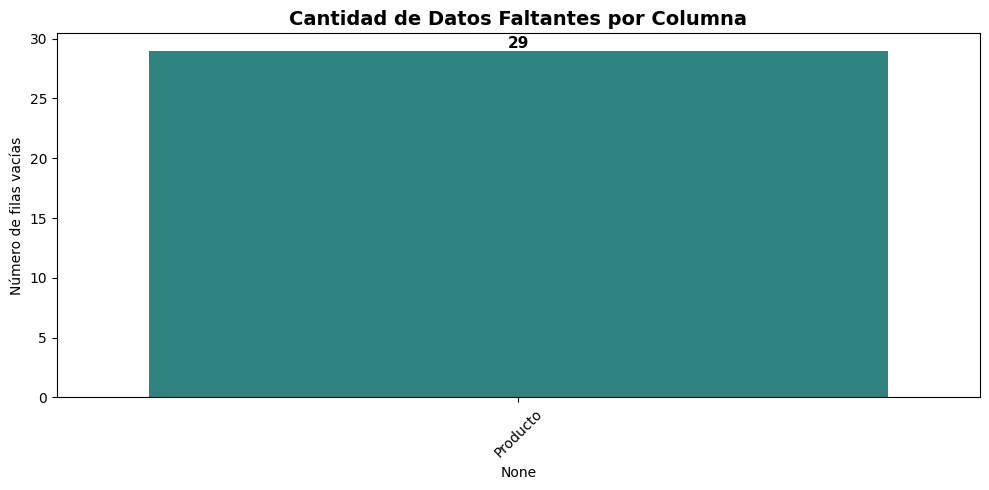


MUESTRA DE FILAS CON DATOS FALTANTES
Total de filas incompletas: 29
Primeras 5 filas con problemas:
            Ciudad      Fecha Producto       Tipo_Producto  Cantidad  \
11939       Bogotá 2025-11-28      NaN  Alimento_Percedero         5   
50716      Chicago 2025-11-27      NaN           Abarrotes         3   
68516    Cartagena 2025-11-15      NaN              Bebida         3   
100252  Valparaíso 2025-11-21      NaN               Snack         3   
129188   Barcelona 2025-11-30      NaN               Snack         2   

        Precio_Unitario     Tipo_Venta Tipo_Cliente  Descuento   Costo_Envio  \
11939       3916.941176         Online    Minorista   0.150000  0.000000e+00   
50716       2975.833333    Call_Center    Mayorista   0.200000  5.000000e+03   
68516       4798.750000  Tienda_Física  Corporativo   0.200000  1.818989e-12   
100252     69150.000000         Online     Gobierno   0.964001  5.000000e+03   
129188      4568.823529    Call_Center    Minorista   0.150000  1.

In [34]:
total_rows = df.shape[0]
null_counts = df.isnull().sum()
null_pct = (df.isnull().mean() * 100).round(2)

reporte_nulos = pd.DataFrame({
    'Nulos (Cantidad)': null_counts,
    'Nulos (%)': null_pct,
    'Tipo de Dato': df.dtypes
})

# Filtramos para mostrar SOLO las columnas que tienen problemas
reporte_filtrado = reporte_nulos[reporte_nulos['Nulos (Cantidad)'] > 0].sort_values(by='Nulos (Cantidad)', ascending=False)

if reporte_filtrado.empty:
    print("\n¡FELICIDADES! No hay valores nulos en ninguna columna.")
    print("   El dataset está 100% completo y listo para PostgreSQL.")
else:
    print(f"\nSE ENCONTRARON NULOS EN {len(reporte_filtrado)} COLUMNAS:\n")
    print(reporte_filtrado)

    # 2. VISUALIZACIÓN GRÁFICA (Barras)
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(x=reporte_filtrado.index, y=reporte_filtrado['Nulos (Cantidad)'], palette='viridis')
    
    plt.title('Cantidad de Datos Faltantes por Columna', fontsize=14, fontweight='bold')
    plt.ylabel('Número de filas vacías')
    plt.xticks(rotation=45)
    
    # Poner el número encima de la barra
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

    # 3. VER LAS FILAS "CULPABLES" (AUDITORÍA)
    print(f"\n{'='*50}")
    print("MUESTRA DE FILAS CON DATOS FALTANTES")
    print(f"{'='*50}")
    
    # Mostramos las primeras 5 filas que tengan AL MENOS un dato nulo
    filas_sucias = df[df.isnull().any(axis=1)]
    print(f"Total de filas incompletas: {len(filas_sucias)}")
    print("Primeras 5 filas con problemas:")
    print(filas_sucias.head())

#### We are going to delete 29 datas from productos

## Delete duplicates

In [35]:
print(f"\n{'='*50}")
print(" LIMPIEZA FINAL: NULOS RESTANTES Y DUPLICADOS")
print(f"{'='*50}")

# 1. ELIMINAR LOS 29 PRODUCTOS NULOS (Decisión tomada: borrar en lugar de imputar)
nulos_prod = df['Producto'].isnull().sum()
if nulos_prod > 0:
    print(f"Eliminando {nulos_prod} filas con 'Producto' nulo...")
    df.dropna(subset=['Producto'], inplace=True)
else:
    print("No hay nulos en Producto.")

# 2. ELIMINAR DUPLICADOS (Tu lógica de negocio)
# Definimos las columnas que hacen única a una transacción, ignorando la auditoría
cols_negocio = [c for c in df.columns if c != 'Origen_Dato']

n_duplicados = df.duplicated(subset=cols_negocio, keep='first').sum()

if n_duplicados > 0:
    print(f"Se detectaron {n_duplicados} filas duplicadas (mismos datos de negocio).")
    
    filas_antes = len(df)
    # Eliminamos duplicados basándonos solo en columnas de negocio
    df = df.drop_duplicates(subset=cols_negocio, keep='first').reset_index(drop=True)
    filas_despues = len(df)
    
    print(f"Se eliminaron {filas_antes - filas_despues} filas duplicadas.")
    print(f"Total de filas finales: {filas_despues}")
else:
    print(" No se encontraron duplicados. El dataset es único.")

print("-" * 30)
print("Estado Final de Nulos (Debe ser todo 0):")
print(df.isnull().sum())


 LIMPIEZA FINAL: NULOS RESTANTES Y DUPLICADOS
Eliminando 29 filas con 'Producto' nulo...
Se detectaron 15606 filas duplicadas (mismos datos de negocio).
Se eliminaron 15606 filas duplicadas.
Total de filas finales: 984365
------------------------------
Estado Final de Nulos (Debe ser todo 0):
Ciudad             0
Fecha              0
Producto           0
Tipo_Producto      0
Cantidad           0
Precio_Unitario    0
Tipo_Venta         0
Tipo_Cliente       0
Descuento          0
Costo_Envio        0
Venta_Total        0
Origen_Dato        0
dtype: int64


# Conection to POSTGRESQL

In [36]:
# ---------------------------------------------------------
# 1. DIMENSIÓN PRODUCTO (Con tu lógica de SKU)
# ---------------------------------------------------------
cols_prod = ['Producto', 'Tipo_Producto']
dim_producto = df[cols_prod].drop_duplicates().reset_index(drop=True)
dim_producto.index.name = 'index' # limpieza interna
dim_producto['id_producto'] = dim_producto.index + 1

# Generación de SKU (Tu lógica)
dim_producto['sku'] = (
    dim_producto['Producto'].astype(str).str[:3].str.upper() + "-" + 
    dim_producto['Tipo_Producto'].astype(str).str[:3].str.upper() + "-" + 
    dim_producto['id_producto'].astype(str).str.zfill(3)
)

# Reordenamos columnas
dim_producto = dim_producto[['id_producto', 'sku', 'Producto', 'Tipo_Producto']]
dim_producto.columns = ['id_producto', 'sku', 'nombre_producto', 'categoria'] # Nombres para SQL

print(f"Dimensión Producto creada: {len(dim_producto)} items.")

# ---------------------------------------------------------
# 2. DIMENSIÓN CLIENTE (Separada para esquema estrella puro)
# ---------------------------------------------------------
dim_cliente = df[['Tipo_Cliente']].drop_duplicates().reset_index(drop=True)
dim_cliente['id_cliente'] = dim_cliente.index + 1
dim_cliente.columns = ['tipo_cliente', 'id_cliente'] # Renombrar para merge
dim_cliente = dim_cliente[['id_cliente', 'tipo_cliente']]

print(f"Dimensión Cliente creada: {len(dim_cliente)} perfiles.")

# ---------------------------------------------------------
# 3. DIMENSIÓN UBICACIÓN (Geografía)
# ---------------------------------------------------------
dim_ubicacion = df[['Ciudad']].drop_duplicates().reset_index(drop=True)
dim_ubicacion['id_ubicacion'] = dim_ubicacion.index + 1
dim_ubicacion.columns = ['ciudad', 'id_ubicacion']
dim_ubicacion = dim_ubicacion[['id_ubicacion', 'ciudad']]

print(f"Dimensión Ubicación creada: {len(dim_ubicacion)} ciudades.")

# ---------------------------------------------------------
# 4. DIMENSIÓN CANAL / TIPO VENTA
# ---------------------------------------------------------
dim_canal = df[['Tipo_Venta']].drop_duplicates().reset_index(drop=True)
dim_canal['id_canal'] = dim_canal.index + 1
dim_canal.columns = ['tipo_venta', 'id_canal']
dim_canal = dim_canal[['id_canal', 'tipo_venta']]

print(f"Dimensión Canal creada: {len(dim_canal)} canales.")

# ---------------------------------------------------------
# 5. TABLA DE HECHOS (FACT_VENTAS)
# ---------------------------------------------------------
print("Cruzando datos para generar Fact Table...")

# Hacemos merge con las dimensiones para obtener los IDs
df_fact = df.merge(dim_producto, left_on=['Producto', 'Tipo_Producto'], right_on=['nombre_producto', 'categoria'], how='left')
df_fact = df_fact.merge(dim_cliente, left_on='Tipo_Cliente', right_on='tipo_cliente', how='left')
df_fact = df_fact.merge(dim_ubicacion, left_on='Ciudad', right_on='ciudad', how='left')
df_fact = df_fact.merge(dim_canal, left_on='Tipo_Venta', right_on='tipo_venta', how='left')

# Seleccionamos solo IDs y Métricas (Normalización completa)
fact_ventas = df_fact[[
    'Fecha', 
    'id_producto', 
    'id_cliente', 
    'id_ubicacion', 
    'id_canal', 
    'Cantidad', 
    'Precio_Unitario', 
    'Descuento', 
    'Costo_Envio', 
    'Venta_Total'
]].copy()

# Renombrar columnas para coincidir con SQL standard (minúsculas)
fact_ventas.columns = [
    'fecha', 'id_producto', 'id_cliente', 'id_ubicacion', 'id_canal', 
    'cantidad', 'precio_unitario', 'descuento', 'costo_envio', 'venta_total'
]

# Crear ID único de venta
fact_ventas.reset_index(inplace=True)
fact_ventas.rename(columns={'index': 'id_venta'}, inplace=True)
fact_ventas['id_venta'] = fact_ventas['id_venta'] + 1

print(f"Fact Table lista con {len(fact_ventas)} transacciones.")

Dimensión Producto creada: 8 items.
Dimensión Cliente creada: 4 perfiles.
Dimensión Ubicación creada: 33 ciudades.
Dimensión Canal creada: 4 canales.
Cruzando datos para generar Fact Table...
Fact Table lista con 984365 transacciones.


## Uploaded to POSTGRESQL

In [37]:
import os

print(f"\n{'='*50}")
print(" ELIMINANDO COLUMNA DE AUDITORÍA Y EXPORTANDO CSVs")
print(f"{'='*50}")

# 1. Definir ruta de exportación (Carpeta '../Data')
ruta_notebook = os.getcwd()
ruta_data = os.path.abspath(os.path.join(ruta_notebook, '..', 'Data'))

# Crear carpeta si no existe
if not os.path.exists(ruta_data):
    os.makedirs(ruta_data)
    print(f"Carpeta creada: {ruta_data}")
else:
    print(f"Carpeta destino: {ruta_data}")

# 2. Eliminar 'Origen_Dato' (Limpieza Final)
# Verificamos tanto en el DF principal como en la Fact Table
columnas_a_borrar = ['Origen_Dato', 'origen_dato'] # Por si está en mayúscula o minúscula

# A) En el DataFrame Maestro
for col in columnas_a_borrar:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)
        print(f"✅ Columna '{col}' eliminada del DataFrame Maestro.")

# B) En la Fact Table (Si ya la creaste)
if 'fact_ventas' in locals():
    for col in columnas_a_borrar:
        if col in fact_ventas.columns:
            fact_ventas.drop(columns=[col], inplace=True)
            print(f"✅ Columna '{col}' eliminada de fact_ventas.")

# 3. Exportación Masiva a CSV
print("\n💾 Guardando archivos...")

try:
    # 1. Base Maestra Completa (Backup General)
    df.to_csv(os.path.join(ruta_data, 'RIWI_Ventas_Master_Limpia.csv'), index=False)
    print("   -> RIWI_Ventas_Master_Limpia.csv OK")

    # 2. Dimensiones (Modelo Estrella)
    if 'dim_producto' in locals():
        dim_producto.to_csv(os.path.join(ruta_data, 'dim_producto.csv'), index=False)
        print("   -> dim_producto.csv OK")

    if 'dim_cliente' in locals():
        dim_cliente.to_csv(os.path.join(ruta_data, 'dim_cliente.csv'), index=False)
        print("   -> dim_cliente.csv OK")

    if 'dim_ubicacion' in locals():
        dim_ubicacion.to_csv(os.path.join(ruta_data, 'dim_ubicacion.csv'), index=False)
        print("   -> dim_ubicacion.csv OK")

    if 'dim_canal' in locals():
        dim_canal.to_csv(os.path.join(ruta_data, 'dim_canal.csv'), index=False)
        print("   -> dim_canal.csv OK")

    # 3. Hechos (Fact Table)
    if 'fact_ventas' in locals():
        fact_ventas.to_csv(os.path.join(ruta_data, 'fact_ventas.csv'), index=False)
        print("   -> fact_ventas.csv OK")

    print(f"\n🎉 ¡PROCESO TERMINADO! Todos los archivos están en: {ruta_data}")

except Exception as e:
    print(f"❌ Error al guardar: {e}")


 ELIMINANDO COLUMNA DE AUDITORÍA Y EXPORTANDO CSVs
Carpeta destino: c:\Users\coder\Downloads\Ventas - Roberto Gomez\Data
✅ Columna 'Origen_Dato' eliminada del DataFrame Maestro.

💾 Guardando archivos...
   -> RIWI_Ventas_Master_Limpia.csv OK
   -> dim_producto.csv OK
   -> dim_cliente.csv OK
   -> dim_ubicacion.csv OK
   -> dim_canal.csv OK
   -> fact_ventas.csv OK

🎉 ¡PROCESO TERMINADO! Todos los archivos están en: c:\Users\coder\Downloads\Ventas - Roberto Gomez\Data


In [38]:



# Obtenemos la ruta donde está el notebook actualmente
ruta_notebook = os.getcwd()

# Calculamos la ruta de la carpeta PADRE (Ventas - Roberto Gomez)
ruta_raiz = os.path.abspath(os.path.join(ruta_notebook, '..'))

# Le decimos a Python: "Busca archivos también en la carpeta raíz"
if ruta_raiz not in sys.path:
    sys.path.append(ruta_raiz)

print(f"Ruta agregada al sistema: {ruta_raiz}")

# AHORA SÍ podemos importar el archivo que está afuera
from db_connect import get_db_engine

# ==============================================================================
# 2. SUBIR LOS DATOS A POSTGRESQL
# ==============================================================================

print(f"\n{'='*50}")
print(" 🚀 INICIANDO CARGA A LA BASE DE DATOS")
print(f"{'='*50}")

# Obtenemos la conexión usando tu script
engine = get_db_engine()

if engine:
    try:
        with engine.connect() as conn:
            # 1. Limpiar tablas viejas para evitar errores de duplicados
            print("🧹 Limpiando tablas en PostgreSQL (TRUNCATE)...")
            # El CASCADE es vital para borrar la Fact Table y luego las dimensiones sin errores de FK
            conn.execute(text("TRUNCATE TABLE fact_ventas, dim_producto, dim_cliente, dim_ubicacion, dim_canal RESTART IDENTITY CASCADE;"))
            conn.commit()
            print("   Tablas limpias y listas.")

        # Función para subir dataframes
        def cargar_tabla(df, nombre_sql):
            if df is not None and not df.empty:
                print(f"⏳ Subiendo '{nombre_sql}' ({len(df)} filas)...")
                df.to_sql(
                    nombre_sql, 
                    engine, 
                    if_exists='append', # 'append' respeta las llaves foráneas que creaste en DBeaver
                    index=False, 
                    method='multi', 
                    chunksize=2000
                )
                print(f"'{nombre_sql}' completado.")
            else:
                print(f"Saltando '{nombre_sql}' (DataFrame vacío o no existe).")

        # ---------------------------------------------------------
        # IMPORTANTE: El orden importa por las Llaves Foráneas
        # Primero Dimensiones -> Luego Hechos
        # ---------------------------------------------------------
        
        # Cargar Dimensiones
        if 'dim_producto' in locals(): cargar_tabla(dim_producto, 'dim_producto')
        if 'dim_cliente' in locals():  cargar_tabla(dim_cliente, 'dim_cliente')
        if 'dim_ubicacion' in locals(): cargar_tabla(dim_ubicacion, 'dim_ubicacion')
        if 'dim_canal' in locals():    cargar_tabla(dim_canal, 'dim_canal')

        # Cargar Hechos (Fact Table)
        if 'fact_ventas' in locals():
            print(f"Subiendo 'fact_ventas' (esto puede tardar)...")
            fact_ventas.to_sql('fact_ventas', engine, if_exists='append', index=False, chunksize=5000)
            print(f"¡FACT_VENTAS CARGADA! ({len(fact_ventas)} registros)")

        print(f"\n{'='*50}")
        print(" ¡TODO LISTO! Ve a Power BI y conéctate.")
        print(f"{'='*50}")

    except Exception as e:
        print(f"\nERROR CRÍTICO: {e}")
        print("   -> Revisa que hayas corrido el script SQL en DBeaver para crear las tablas primero.")
else:
    print("No se pudo conectar. Revisa tu archivo .env y db_connect.py")

Ruta agregada al sistema: c:\Users\coder\Downloads\Ventas - Roberto Gomez

 🚀 INICIANDO CARGA A LA BASE DE DATOS
🧹 Limpiando tablas en PostgreSQL (TRUNCATE)...
   Tablas limpias y listas.
⏳ Subiendo 'dim_producto' (8 filas)...
'dim_producto' completado.
⏳ Subiendo 'dim_cliente' (4 filas)...
'dim_cliente' completado.
⏳ Subiendo 'dim_ubicacion' (33 filas)...
'dim_ubicacion' completado.
⏳ Subiendo 'dim_canal' (4 filas)...
'dim_canal' completado.
Subiendo 'fact_ventas' (esto puede tardar)...
¡FACT_VENTAS CARGADA! (984365 registros)

 ¡TODO LISTO! Ve a Power BI y conéctate.
